## **Read data and Imports**

In [63]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')

if gpus:
    tf.config.set_logical_device_configuration(
        gpus[0],
        [tf.config.LogicalDeviceConfiguration(memory_limit=3000)]
    )

In [ ]:
import pandas as pd
import tensorflow as tf
import shap
from lime import lime_image
from skimage.segmentation import mark_boundaries
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from skrebate import ReliefF
import missingno as msno
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import os
import random
import cv2 as cv2
import sklearn
from sklearn.feature_selection import (
    mutual_info_regression,  # Information Gain
    chi2,                    # Chi-square Test
    f_classif,               # ANOVA (F-test)
    SelectKBest,             # Select top k features
    VarianceThreshold        # Variance Threshold
)
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [65]:
data = pd.read_csv("../../Data/dataset_split/train/train.csv")

## **Preprocessing**

**Feature Engineering**

In [91]:
data2 = data.copy()
data2.drop(columns=['image_id','patient_id'],inplace = True)

In [92]:
data2.drop(columns=['nationality'],inplace=True)
data2.drop(columns=['insuline'],inplace=True)
data2.drop(columns=['focus', 'Illuminaton', 'image_field', 'artifacts'],inplace=True)
data2.drop(columns=['diabetes_time_y','comorbidities'],inplace=True)
data2.drop(columns=['camera'],inplace=True)
data2.drop(columns=['quality'],inplace=True)
data2.drop(columns=['other'],inplace=True)
# high correlated with X feature
data2.drop(columns=['DR_SDRG','DR_ICDR'],inplace=True)

In [93]:
data2['exam_eye'] = data2['exam_eye'].map({1: 0, 2: 1})

data2['vessels'] = data2['vessels'].map({1: 0, 2: 1})

data2['macula'] = data2['macula'].map({1: 0, 2: 1})

data2['patient_sex'] = data2['patient_sex'].map({1: 0, 2: 1})

data2['diabetes'] = data2['diabetes'].map({'yes': 1, 'No': 0})

data2['optic_disc'] = data2['optic_disc'].map({1: 0, 2: 1})

In [94]:
count = 1
for col in data2.columns:
    print(f"{count}. Unique Values for [ {col} ] is : ",data2[col].unique(),'\n')
    count+=1

1. Unique Values for [ patient_age ] is :  [48. 18. 22. 23. 14. 20. 28. 37. 21. 16. 24. 26. 19. 17. 13. 27. 39. 25.
 30. 15. 29. 57. 44. 38. 47. 42. 10. 59. 32. 66. 82. 87. 80. 41. 76. 71.
 73. 83. 45. 61. 55. 75. 81. 72. 64. 46. 74. 65. 31. 33. 53. 50. 51. 49.
 63. 62. 52. 70. 79. 60. 78. 54. 56. 77. 58. 85. 86. 84. 69. 11. 68. nan
  9. 91. 36. 90. 67. 88.  7. 35. 40. 43. 89. 34. 12.  8. 95. 97.  6. 93.
 94.  5. 92.] 

2. Unique Values for [ patient_sex ] is :  [0 1] 

3. Unique Values for [ exam_eye ] is :  [0 1] 

4. Unique Values for [ diabetes ] is :  [1 0] 

5. Unique Values for [ optic_disc ] is :  [0 1] 

6. Unique Values for [ vessels ] is :  [0 1] 

7. Unique Values for [ macula ] is :  [0 1] 

8. Unique Values for [ diabetic_retinopathy ] is :  [0 1] 

9. Unique Values for [ macular_edema ] is :  [0 1] 

10. Unique Values for [ scar ] is :  [0 1] 

11. Unique Values for [ nevus ] is :  [0 1] 

12. Unique Values for [ amd ] is :  [0 1] 

13. Unique Values for [ vascular_occlu

In [95]:
def show_missing(data2):
    """
    Visualizes and reports missing values in a Pandas data2Frame.

    Parameters:
    - data2 (data2Frame): The input Pandas data2Frame to check for missing values.

    Returns:
    None

    This function performs the following tasks:
    1. Displays a missing data2 matrix plot to visualize the location of missing values in the data2Frame.
    2. Prints the percentage of missing values in each column with missing data2.
    3. Creates a bar plot to visualize the percentage of missing values in each column.

    Example usage:
    show_missing(data2)
    """
    
    # Visualize the percentage of missing data2 using a bar plot
    msno.matrix(data2)
    
    
    # Print the percentage of missing values in the columns with missing
    features_with_nan = [features for features in data2.columns if data2[features].isnull().sum()>=1]
    print(f'{len(features_with_nan)} columns with missing values detected:')

    for features in features_with_nan:
        print(features , np.round(data2[features].isnull().mean(),4) * 100 , '% missing values')

    
    # Create a bar plot to visualize missing values
    # Calculate the percentage of missing data2 in each column
    missing_percentage = data2.isnull().mean() * 100
    missing_percentage
    
    plt.figure(figsize=(10, 6))
    missing_percentage.plot(kind='bar', color='skyblue')
    plt.title('Percentage of Missing Values per Column')
    plt.xlabel('Columns')
    plt.ylabel('Percentage Missing')
    plt.xticks(rotation=90)
    plt.tight_layout()
    
    plt.show()

In [96]:

data2['patient_age'] = data2['patient_age'].fillna(data2['patient_age'].median())

0 columns with missing values detected:


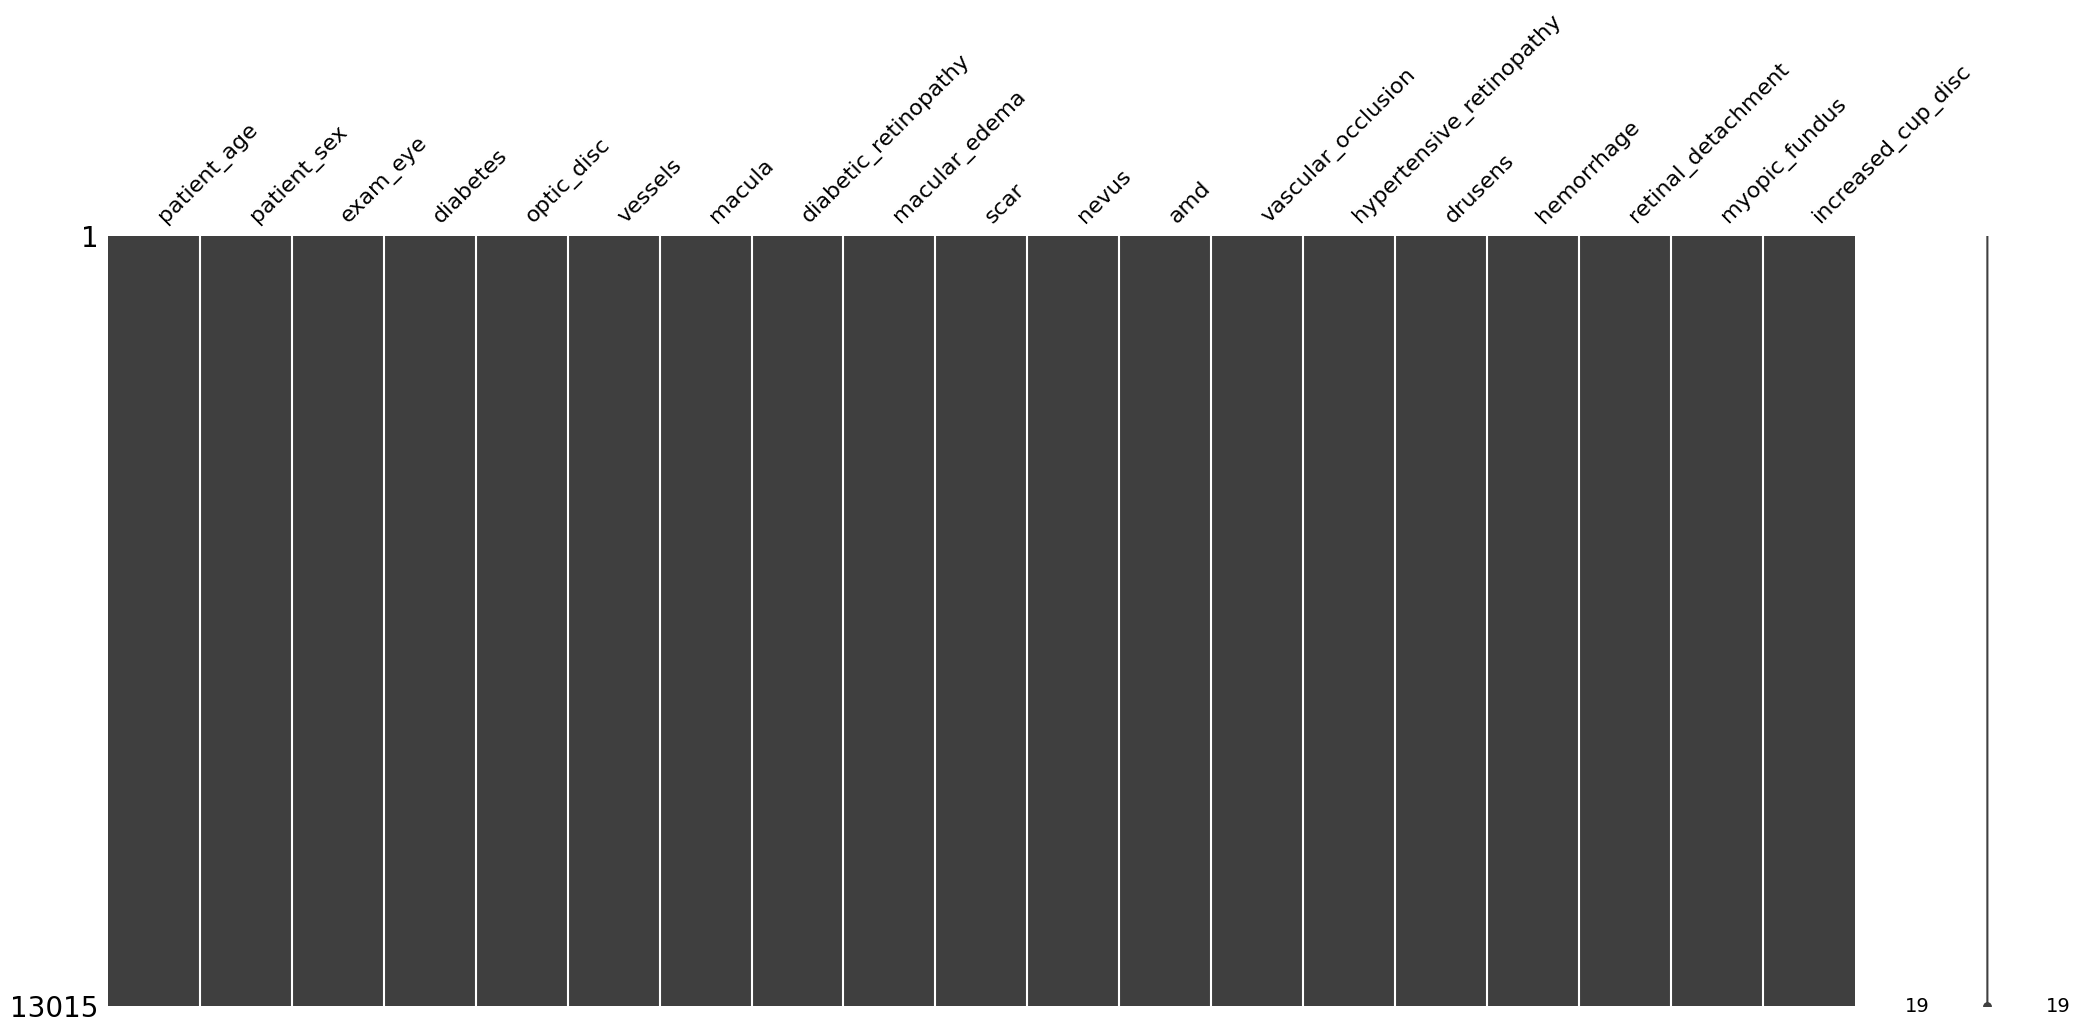

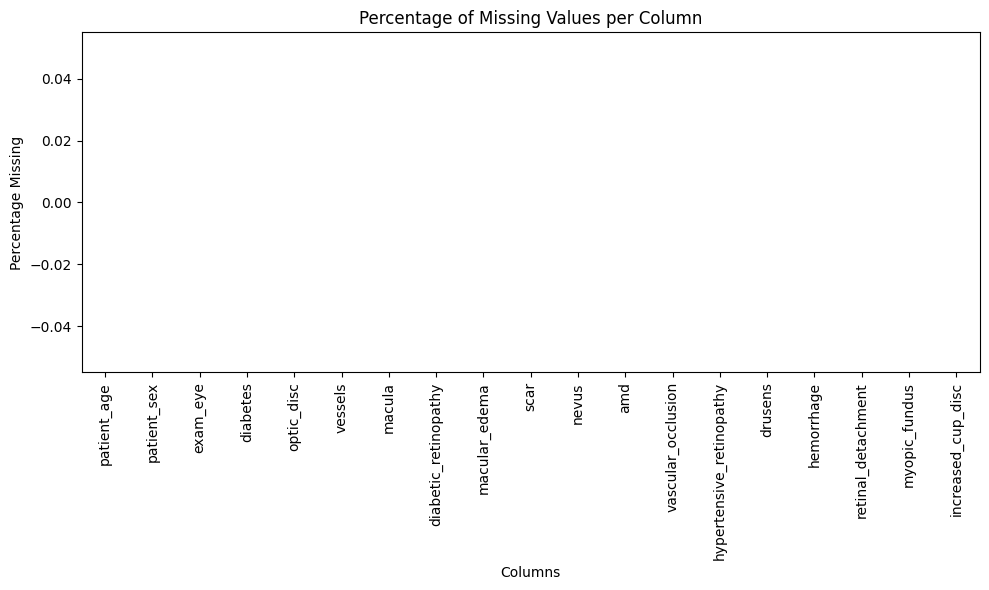

In [97]:
show_missing(data2)

In [98]:
data2_clean = data2.select_dtypes(include=['int64', 'float64'])
# data2_clean.drop(columns=['DR_ICDR'],inplace=True)

## **Feature Selection techniques**

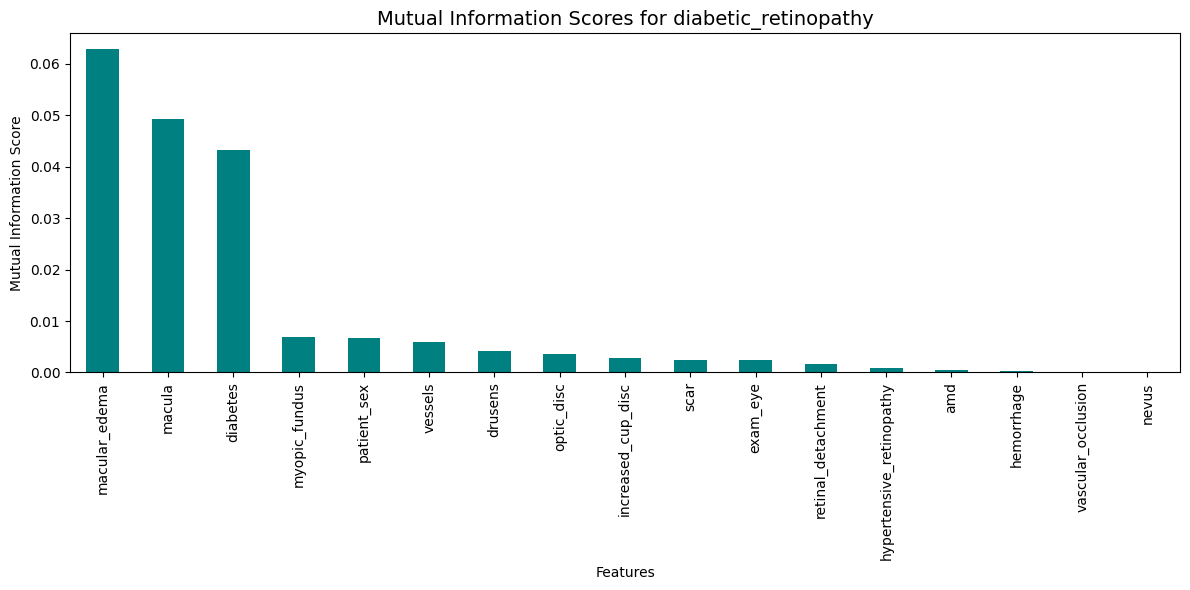

In [99]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif

# 1. Prepare data2
# Ensure we only use numeric data2 and define our single target
data2_clean = data2.select_dtypes(include=['int64', 'float64'])
target = 'diabetic_retinopathy'

# 2. Separate Features and Target
y = data2_clean[target]
X = data2_clean.drop(columns=[target, 'patient_age'], errors='ignore')

# 3. Compute Mutual Information
mi_scores = mutual_info_classif(X, y, random_state=42)

# 4. Convert to Series and Sort
mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

# 5. Initialize a single plot
fig, ax = plt.subplots(figsize=(12, 6))

# 6. Plot
mi_series.plot(kind="bar", color="teal", ax=ax)

# 7. Customizing the plot
ax.set_title(f"Mutual Information Scores for {target}", fontsize=14)
ax.set_ylabel("Mutual Information Score")
ax.set_xlabel("Features")

plt.tight_layout()
plt.show()


Top Chi-square features:

                     Feature   Chi2 Score        p-value  Significant (p<0.05)
0              macular_edema  3831.090810   0.000000e+00                  True
1                   diabetes  1247.905533  2.367328e-273                  True
2                     macula  1034.006334  7.288479e-227                  True
3                    vessels   315.798029   1.191791e-70                  True
4                    drusens    97.171129   6.358709e-23                  True
5         increased_cup_disc    69.794174   6.582702e-17                  True
6                 optic_disc    62.061360   3.329203e-15                  True
7                patient_sex    36.321598   1.672996e-09                  True
8   hypertensive_retinopathy    17.612113   2.708577e-05                  True
9              myopic_fundus    16.966527   3.804468e-05                  True
10                       amd     8.369002   3.816751e-03                  True
11        vascular_occlus

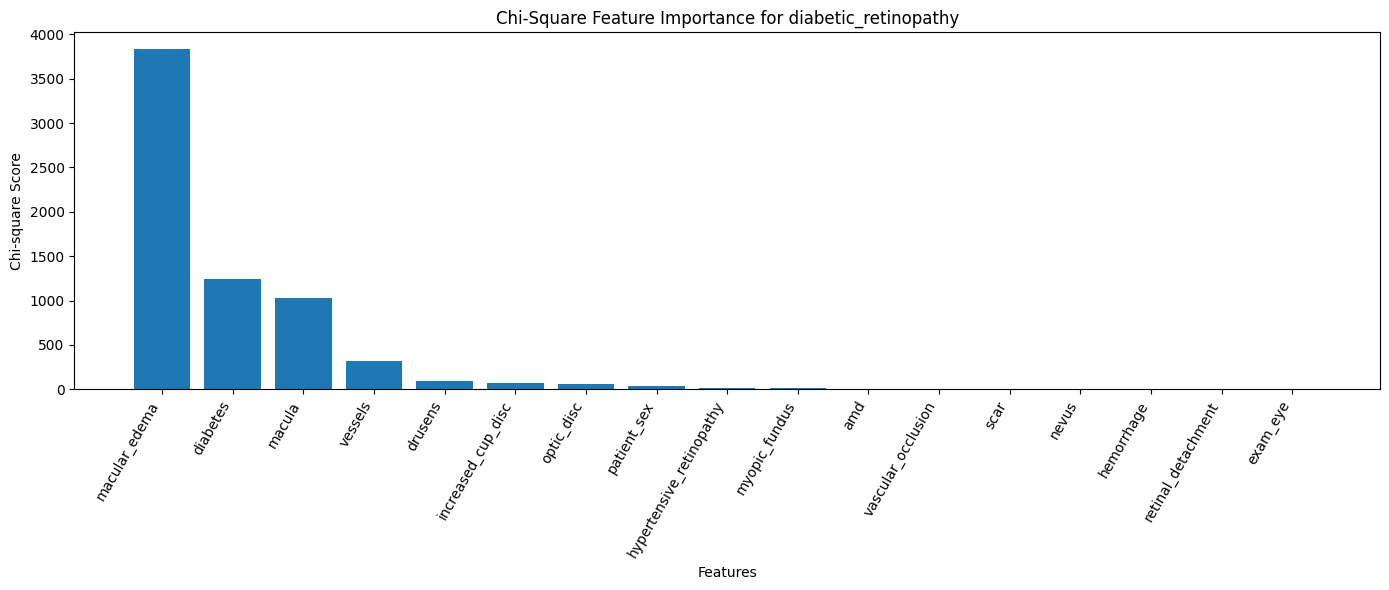

In [100]:
from sklearn.feature_selection import chi2
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

target = 'diabetic_retinopathy'

# =========================
# 1) COPY DATA
# =========================
df = data2.copy()

# =========================
# 2) OPTIONAL: REMOVE DUPLICATE EYE-LEVEL LEAKAGE
#    Since each patient may appear twice (left/right eye),
#    use one row per patient for cleaner tabular feature selection.
#    If you want eye-level analysis, comment this block.
# =========================
if 'patient_id' in df.columns:
    df = df.sort_values(by=['patient_id']).groupby('patient_id', as_index=False).first()

# =========================
# 3) DROP ROWS WITH MISSING TARGET
# =========================
df = df.dropna(subset=[target])

# =========================
# 4) STANDARDIZE TARGET TO 0/1
# =========================
if df[target].dtype == 'object':
    df[target] = df[target].astype(str).str.strip().str.lower().map({
        'yes': 1, 'no': 0,
        'true': 1, 'false': 0,
        '1': 1, '0': 0
    })

df[target] = pd.to_numeric(df[target], errors='coerce')
df = df.dropna(subset=[target])
df[target] = df[target].astype(int)

y = df[target]

# =========================
# 5) DROP CLEARLY USELESS / LEAKY / HIGH-CARDINALITY COLUMNS
# =========================
drop_cols = [
    target,
    'image_id',          # unique ID -> useless for chi2
    'patient_id',        # ID -> useless
    'camera',            # often too specific / low value
    'nationality',       # almost constant in your sample
    'quality',           # text label; can encode separately if needed
    'comorbidities'   # raw messy text; use encoded disease columns instead

]

X = df.drop(columns=[c for c in drop_cols if c in df.columns], errors='ignore')

# =========================
# 6) NORMALIZE YES/NO OBJECT COLUMNS
# =========================
for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = X[col].astype(str).str.strip().str.lower()

        # convert yes/no columns
        if set(X[col].dropna().unique()).issubset({'yes', 'no', 'true', 'false', '0', '1'}):
            X[col] = X[col].map({
                'yes': 1, 'no': 0,
                'true': 1, 'false': 0,
                '1': 1, '0': 0
            })

# =========================
# 7) KEEP ONLY CATEGORICAL / BINARY FEATURES
#    Good for chi-square:
#    - binary columns
#    - low-cardinality integer columns
#    - remaining object/category columns
#    Exclude continuous numeric columns
# =========================
categorical_cols = []

for col in X.columns:
    series = X[col]

    # object/category columns
    if series.dtype == 'object' or str(series.dtype) == 'category':
        categorical_cols.append(col)

    # integer/binary categorical columns
    elif pd.api.types.is_integer_dtype(series) and series.nunique(dropna=True) <= 10:
        categorical_cols.append(col)

    # sometimes float columns are actually binary/categorical because of NaNs
    elif pd.api.types.is_float_dtype(series):
        unique_vals = set(series.dropna().unique())
        if unique_vals.issubset({0.0, 1.0, 2.0, 3.0, 4.0}):
            categorical_cols.append(col)

X_cat = X[categorical_cols].copy()

# =========================
# 8) ONE-HOT ENCODE REMAINING OBJECT/CATEGORY COLUMNS
# =========================
X_cat = pd.get_dummies(X_cat, drop_first=False)

# =========================
# 9) FILL MISSING VALUES
# =========================
X_cat = X_cat.fillna(0)

# =========================
# 10) ENSURE ALL FEATURES ARE NON-NEGATIVE
#     chi2 requires non-negative inputs
# =========================
for col in X_cat.columns:
    X_cat[col] = pd.to_numeric(X_cat[col], errors='coerce').fillna(0)

X_cat = X_cat.loc[:, (X_cat.min(axis=0) >= 0)]

# =========================
# 11) REMOVE CONSTANT COLUMNS
# =========================
X_cat = X_cat.loc[:, X_cat.nunique() > 1]

# =========================
# 12) CHI-SQUARE
# =========================
chi_scores, p_values = chi2(X_cat, y)

# =========================
# 13) RESULTS TABLE
# =========================
chi_df = pd.DataFrame({
    'Feature': X_cat.columns,
    'Chi2 Score': chi_scores,
    'p-value': p_values
})

chi_df = chi_df.sort_values(by='Chi2 Score', ascending=False).reset_index(drop=True)

# =========================
# 14) MARK SIGNIFICANT FEATURES
# =========================
chi_df['Significant (p<0.05)'] = chi_df['p-value'] < 0.05

print("\nTop Chi-square features:\n")
print(chi_df.head(30))

print("\nSignificant features only:\n")
print(chi_df[chi_df['p-value'] < 0.05].head(30))

# =========================
# 15) PLOT TOP FEATURES
# =========================
top_n = min(20, len(chi_df))

plt.figure(figsize=(14, 6))
plt.bar(chi_df['Feature'].head(top_n), chi_df['Chi2 Score'].head(top_n))
plt.title(f'Chi-Square Feature Importance for {target}')
plt.ylabel('Chi-square Score')
plt.xlabel('Features')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

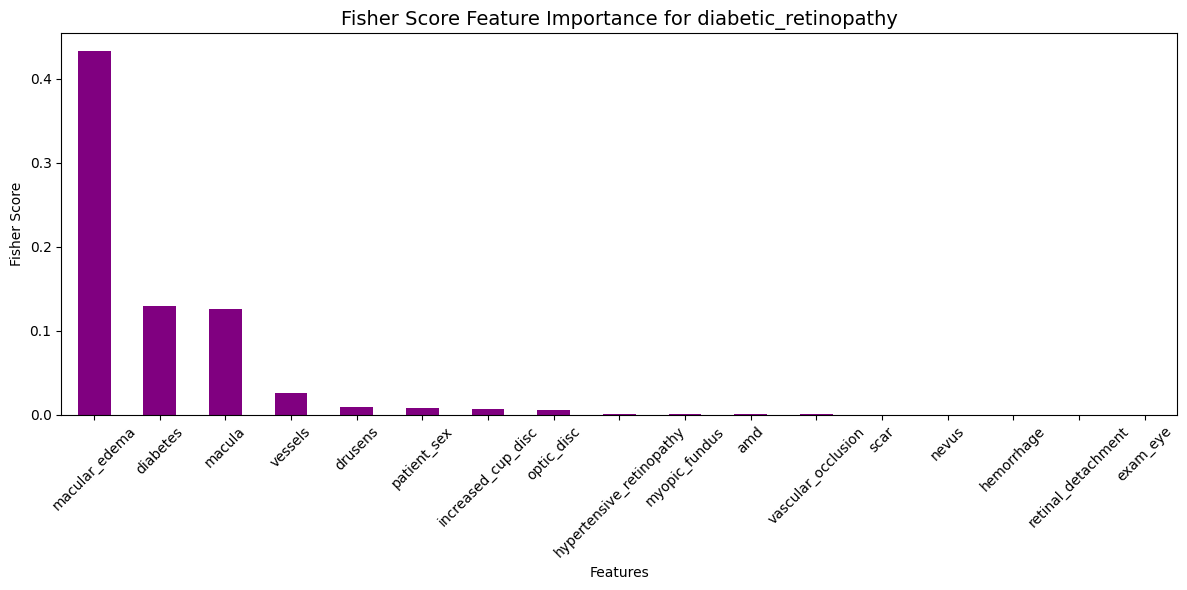

In [101]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def fisher_score(X, y, eps=1e-10):
    classes = np.unique(y)
    overall_mean = np.mean(X, axis=0)

    between_var = np.zeros(X.shape[1])
    within_var = np.zeros(X.shape[1])

    for c in classes:
        X_c = X[y == c]
        mean_c = np.mean(X_c, axis=0)
        n_c = X_c.shape[0]

        between_var += n_c * (mean_c - overall_mean) ** 2
        within_var += np.sum((X_c - mean_c) ** 2, axis=0)

    return between_var / (within_var + eps)

# 2. Prepare base data2
data2_clean = data2.select_dtypes(include=['int64', 'float64'])
target = 'diabetic_retinopathy'

# 3. Separate Features and Target
y = data2_clean[target]
# Dropping target, patient_age, and patient_id to keep features clean
X = data2_clean.drop(columns=[target, 'patient_age', 'patient_id'], errors='ignore')

# 4. Compute Fisher Score
# Converting to numpy as required by your function
fisher_scores = fisher_score(X.to_numpy(), y.to_numpy())

# 5. Convert to Series and Sort
fisher_series = pd.Series(fisher_scores, index=X.columns).sort_values(ascending=False)

# 6. Initialize the plot
plt.figure(figsize=(12, 6))

# 7. Plot
fisher_series.plot(kind='bar', color='purple')

# 8. Customizing the plot
plt.title(f"Fisher Score Feature Importance for {target}", fontsize=14)
plt.ylabel("Fisher Score")
plt.xlabel("Features")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

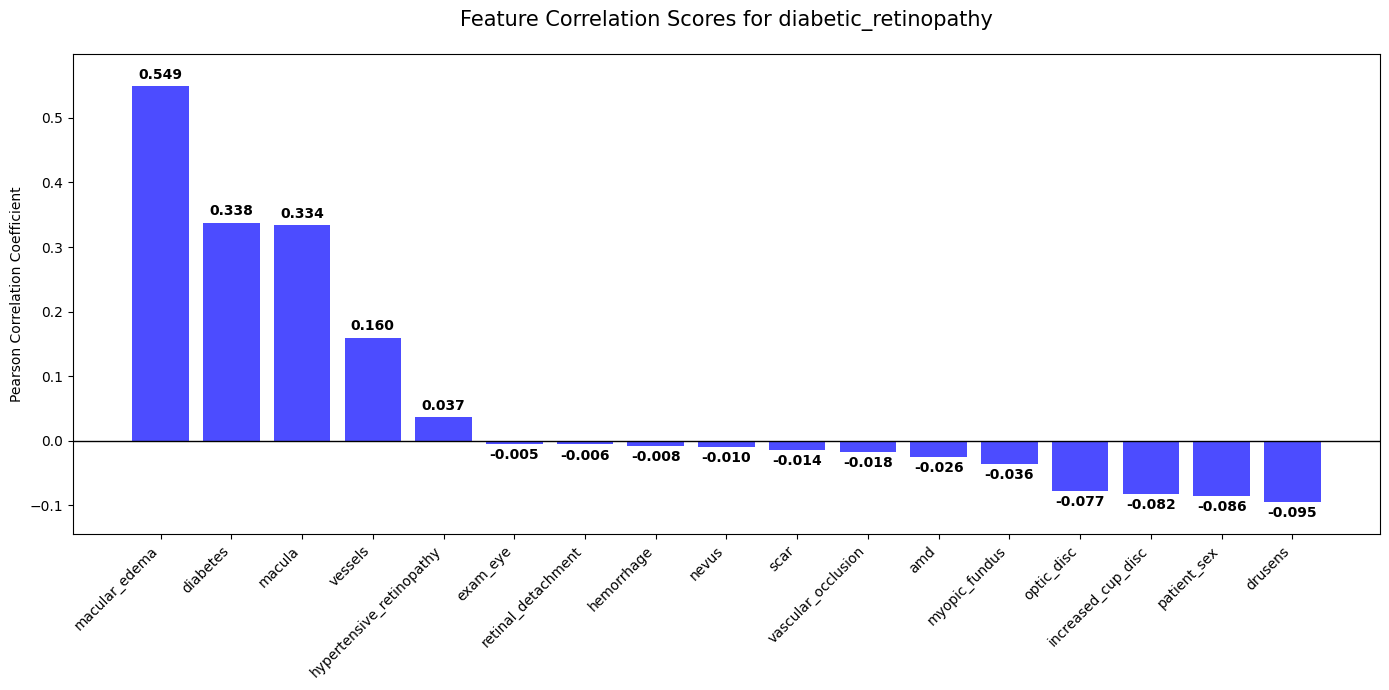

In [102]:

data2_clean = data2.select_dtypes(include=['int64', 'float64'])
target = 'diabetic_retinopathy'
y = data2_clean[target]
X = data2_clean.drop(columns=[target, 'patient_age', 'patient_id'], errors='ignore')

# 2. Compute and Sort Scores
corr_scores = X.apply(lambda col: col.corr(y)).sort_values(ascending=False)

# 3. Create Plot
fig, ax = plt.subplots(figsize=(14, 7))
bars = ax.bar(corr_scores.index, corr_scores.values, color="blue", alpha=0.7)

# 4. Add the numbers above (or below) the bars
# 'fmt="%.3f"' rounds the labels to 3 decimal places
# 'padding=3' adds a little space between the bar and the text
ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=10, fontweight='bold')

# 5. Styling
ax.set_title(f"Feature Correlation Scores for {target}", fontsize=15, pad=20)
ax.set_ylabel("Pearson Correlation Coefficient")
ax.axhline(0, color='black', linewidth=1) # Reference line at zero
plt.xticks(rotation=45, ha='right')
plt.ylim(corr_scores.min() - 0.05, corr_scores.max() + 0.05) # Add room for labels

plt.tight_layout()
plt.show()

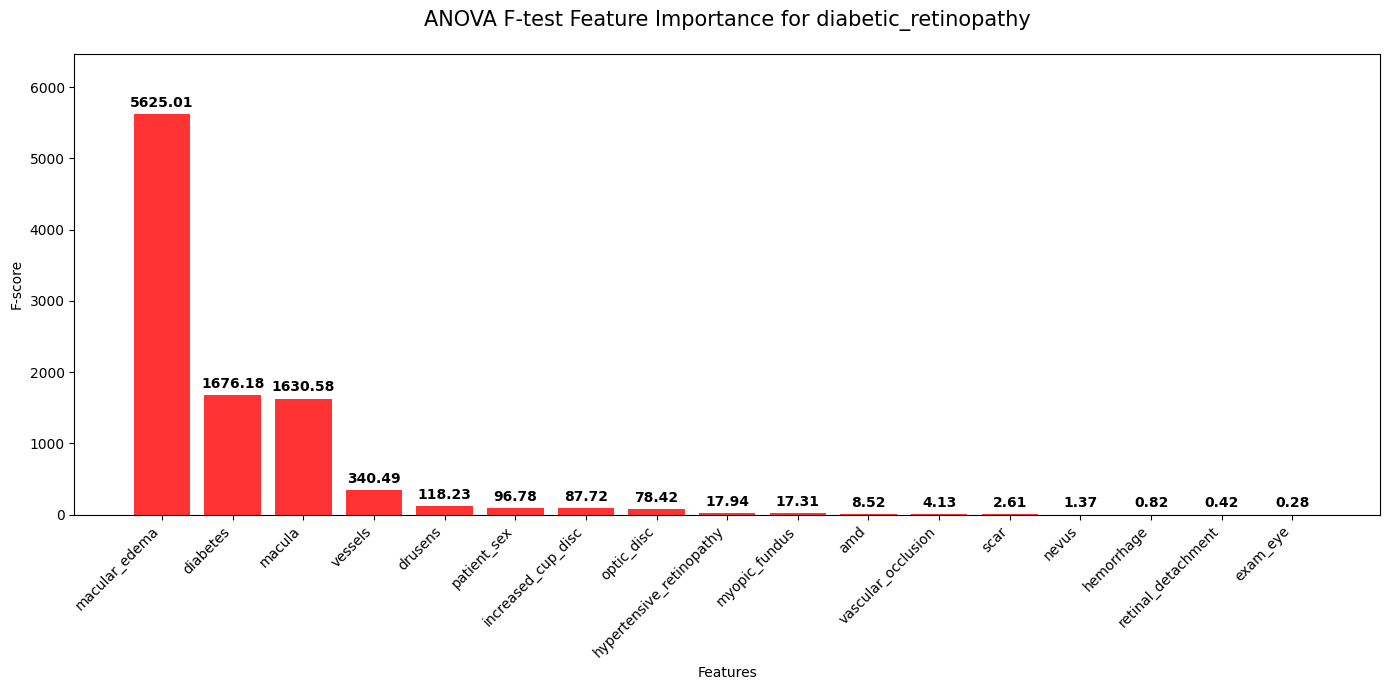

In [103]:

# 1. Prepare base data2
data2_clean = data2.select_dtypes(include=['int64', 'float64'])
target = 'diabetic_retinopathy'

# 2. Separate Features and Target
y = data2_clean[target]
# Dropping target, age, and ID
X = data2_clean.drop(columns=[target, 'patient_age', 'patient_id'], errors='ignore')

# 3. Compute ANOVA F-score
# f_classif returns (F-statistics, p-values). We take the F-statistics.
f_scores, _ = f_classif(X, y)

# 4. Convert to Series and Sort
f_series = pd.Series(f_scores, index=X.columns).sort_values(ascending=False)

# 5. Initialize the plot
fig, ax = plt.subplots(figsize=(14, 7))

# 6. Create the bar chart
# We use ax.bar instead of series.plot to easily grab the containers for labels
bars = ax.bar(f_series.index, f_series.values, color="red", alpha=0.8)

# 7. Add numbers above the bars (Enhanced Visualization)
ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=10, fontweight='bold')

# 8. Customizing the plot
ax.set_title(f"ANOVA F-test Feature Importance for {target}", fontsize=15, pad=20)
ax.set_ylabel("F-score")
ax.set_xlabel("Features")

# Rotate x-axis labels to prevent overlapping
plt.xticks(rotation=45, ha='right')

# Adjust y-limit to give room for the labels at the top
ax.set_ylim(0, f_series.max() * 1.15)

plt.tight_layout()
plt.show()

Features used:
['patient_sex', 'exam_eye', 'diabetes', 'optic_disc', 'vessels', 'macula', 'macular_edema', 'scar', 'nevus', 'amd', 'vascular_occlusion', 'hypertensive_retinopathy', 'drusens', 'hemorrhage', 'retinal_detachment', 'myopic_fundus', 'increased_cup_disc']

ReliefF Feature Importance:
macula                      0.389301
diabetes                    0.139478
drusens                     0.127925
exam_eye                    0.066784
patient_sex                 0.061640
optic_disc                  0.022751
increased_cup_disc          0.020841
macular_edema               0.020484
myopic_fundus               0.013500
amd                         0.013039
vessels                     0.012174
scar                        0.010857
hypertensive_retinopathy    0.005221
vascular_occlusion          0.003976
nevus                       0.002762
hemorrhage                  0.001306
retinal_detachment          0.000015
dtype: float64


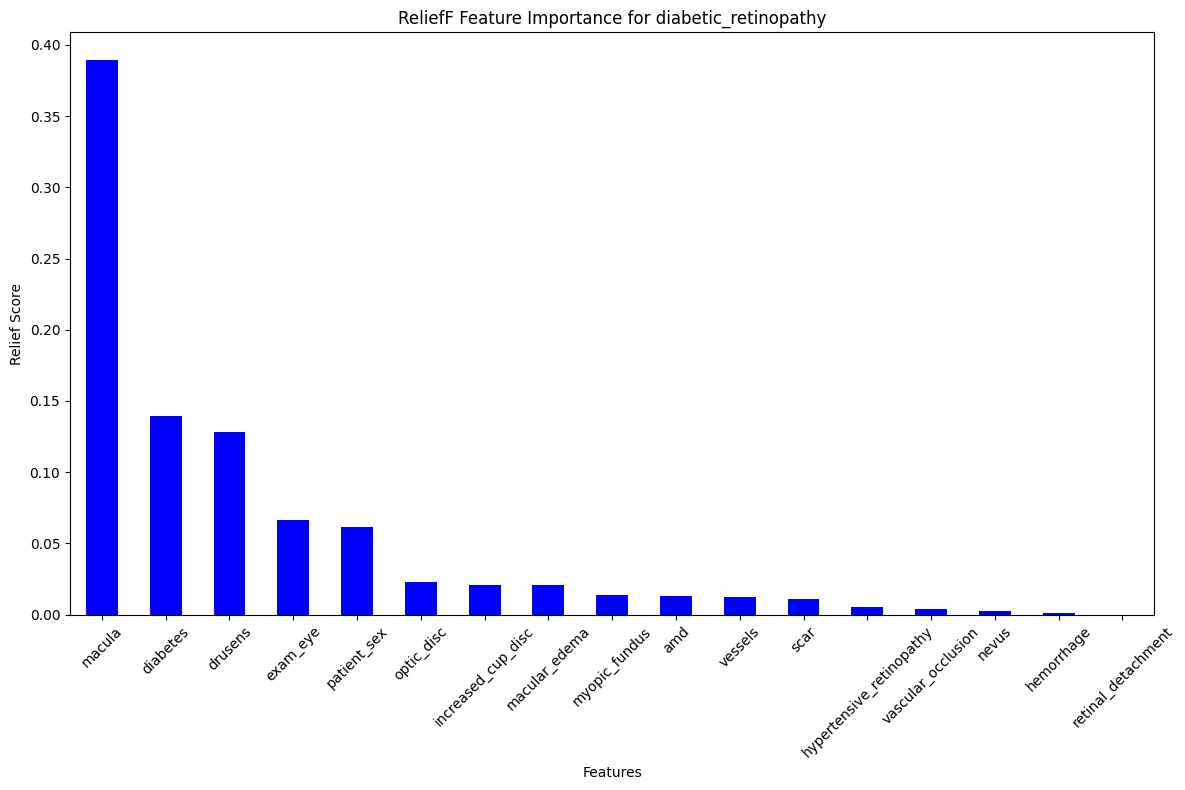

In [104]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import MinMaxScaler
from skrebate import ReliefF

# =========================
# 1) Prepare numeric data2
# =========================
data2_clean = data2.select_dtypes(include=["int64", "float64"]).copy()

# Target
target = "diabetic_retinopathy"
y_temp = data2_clean[target].to_numpy()

# Features
X_temp = data2_clean.drop(columns=[target], errors="ignore").copy()

# Optional: drop patient_age if you don't want to use it
X_temp = X_temp.drop(columns=["patient_age"], errors="ignore")

print("Features used:")
print(X_temp.columns.tolist())

# =========================
# 2) Remove constant features
# =========================
vt = VarianceThreshold(threshold=0.0)
X_var = vt.fit_transform(X_temp)
kept_cols = X_temp.columns[vt.get_support()]

# =========================
# 3) Scale features for ReliefF
# =========================
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_var)

# =========================
# 4) Apply ReliefF
# =========================
relief = ReliefF(
    n_neighbors=20,
    n_features_to_select=X_scaled.shape[1]
)

relief.fit(X_scaled, y_temp)

# =========================
# 5) Collect feature importance
# =========================
relief_scores = pd.Series(relief.feature_importances_, index=kept_cols)
relief_scores = relief_scores.sort_values(ascending=False)

print("\nReliefF Feature Importance:")
print(relief_scores)

# =========================
# 6) Plot
# =========================
plt.figure(figsize=(12, 8))
relief_scores.plot(kind="bar", color="blue")
plt.title("ReliefF Feature Importance for diabetic_retinopathy")
plt.ylabel("Relief Score")
plt.xlabel("Features")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Forward Selection**

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# =========================
# 1. Target & Features
# =========================
target = 'diabetic_retinopathy'

y = data2_clean[target]

X = data2_clean.drop(columns=['diabetic_retinopathy'], errors='ignore')

# =========================
# 2. Model
# =========================
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

# =========================
# 3. Forward Selection
# =========================
remaining_features = list(X.columns)
selected_features = []
selected_scores = []

n_features_to_select = 10

for step in range(n_features_to_select):
    best_feature = None
    best_score = -1
    
    for feature in remaining_features:
        current_features = selected_features + [feature]
        
        score = cross_val_score(
            model,
            X[current_features],
            y,
            cv=3,
            scoring='f1_weighted',
            n_jobs=-1
        ).mean()
        
        if score > best_score:
            best_score = score
            best_feature = feature
    
    selected_features.append(best_feature)
    selected_scores.append(best_score)
    remaining_features.remove(best_feature)
    
    print(f"Step {step+1}: Added '{best_feature}' --> Score = {best_score:.4f}")

# =========================
# 4. Final Output
# =========================
print("\nFinal Selected Features:")
print(selected_features)+

Step 1: Added 'macular_edema' --> Score = 0.9453
Step 2: Added 'amd' --> Score = 0.9454
Step 3: Added 'drusens' --> Score = 0.9454
Step 4: Added 'optic_disc' --> Score = 0.9454
Step 5: Added 'scar' --> Score = 0.9457
Step 6: Added 'nevus' --> Score = 0.9457
Step 7: Added 'hemorrhage' --> Score = 0.9457
Step 8: Added 'macula' --> Score = 0.9457
Step 9: Added 'myopic_fundus' --> Score = 0.9559
Step 10: Added 'vascular_occlusion' --> Score = 0.9595

Final Selected Features:
['macular_edema', 'amd', 'drusens', 'optic_disc', 'scar', 'nevus', 'hemorrhage', 'macula', 'myopic_fundus', 'vascular_occlusion']


In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# =========================
# 1. Target & Features
# =========================
target = 'diabetic_retinopathy'

y = data2_clean[target]

X = data2_clean.drop(columns=[
    'diabetic_retinopathy',
    'DR_ICDR',
    'DR_SDRG',
    'patient_id'
], errors='ignore')

# =========================
# 2. Model
# =========================
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

# =========================
# 3. Backward Selection
# =========================
current_features = list(X.columns)
selected_scores = []

n_features_to_select = 10

while len(current_features) > n_features_to_select:
    
    best_score = -1
    feature_to_remove = None
    
    for feature in current_features:
        temp_features = [f for f in current_features if f != feature]
        
        score = cross_val_score(
            model,
            X[temp_features],
            y,
            cv=3,
            scoring='f1_weighted',
            n_jobs=-1
        ).mean()
        
        if score > best_score:
            best_score = score
            feature_to_remove = feature
    
    current_features.remove(feature_to_remove)
    selected_scores.append(best_score)
    
    print(f"Removed '{feature_to_remove}' --> Score = {best_score:.4f}")

# =========================
# 4. Final Output
# =========================
print("\nFinal Selected Features:")
print(current_features)

Removed 'exam_eye' --> Score = 0.9617
Removed 'hypertensive_retinopathy' --> Score = 0.9618
Removed 'optic_disc' --> Score = 0.9618
Removed 'vessels' --> Score = 0.9616
Removed 'hemorrhage' --> Score = 0.9615
Removed 'retinal_detachment' --> Score = 0.9609
Removed 'nevus' --> Score = 0.9593
Removed 'quality_score' --> Score = 0.9572
Removed 'increased_cup_disc' --> Score = 0.9555

Final Selected Features:
['patient_age', 'patient_sex', 'diabetes', 'macula', 'macular_edema', 'scar', 'amd', 'vascular_occlusion', 'drusens', 'myopic_fundus']


In [ ]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# Target
target = 'diabetic_retinopathy'

# y
y_temp = data2_clean[target]

# X: drop target + leakage columns + ID
X_temp = data2_clean.drop(columns=['diabetic_retinopathy'], errors='ignore')

# Model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

# RFE
rfe = RFE(
    estimator=model,
    n_features_to_select=10,
    step=1
)

rfe.fit(X_temp, y_temp)

# Selected features
selected_features = X_temp.columns[rfe.support_]

# Print final list
print("Selected Features:")
print(selected_features.tolist())

Selected Features:
['patient_age', 'patient_sex', 'diabetes', 'optic_disc', 'vessels', 'macula', 'macular_edema', 'scar', 'drusens', 'myopic_fundus']


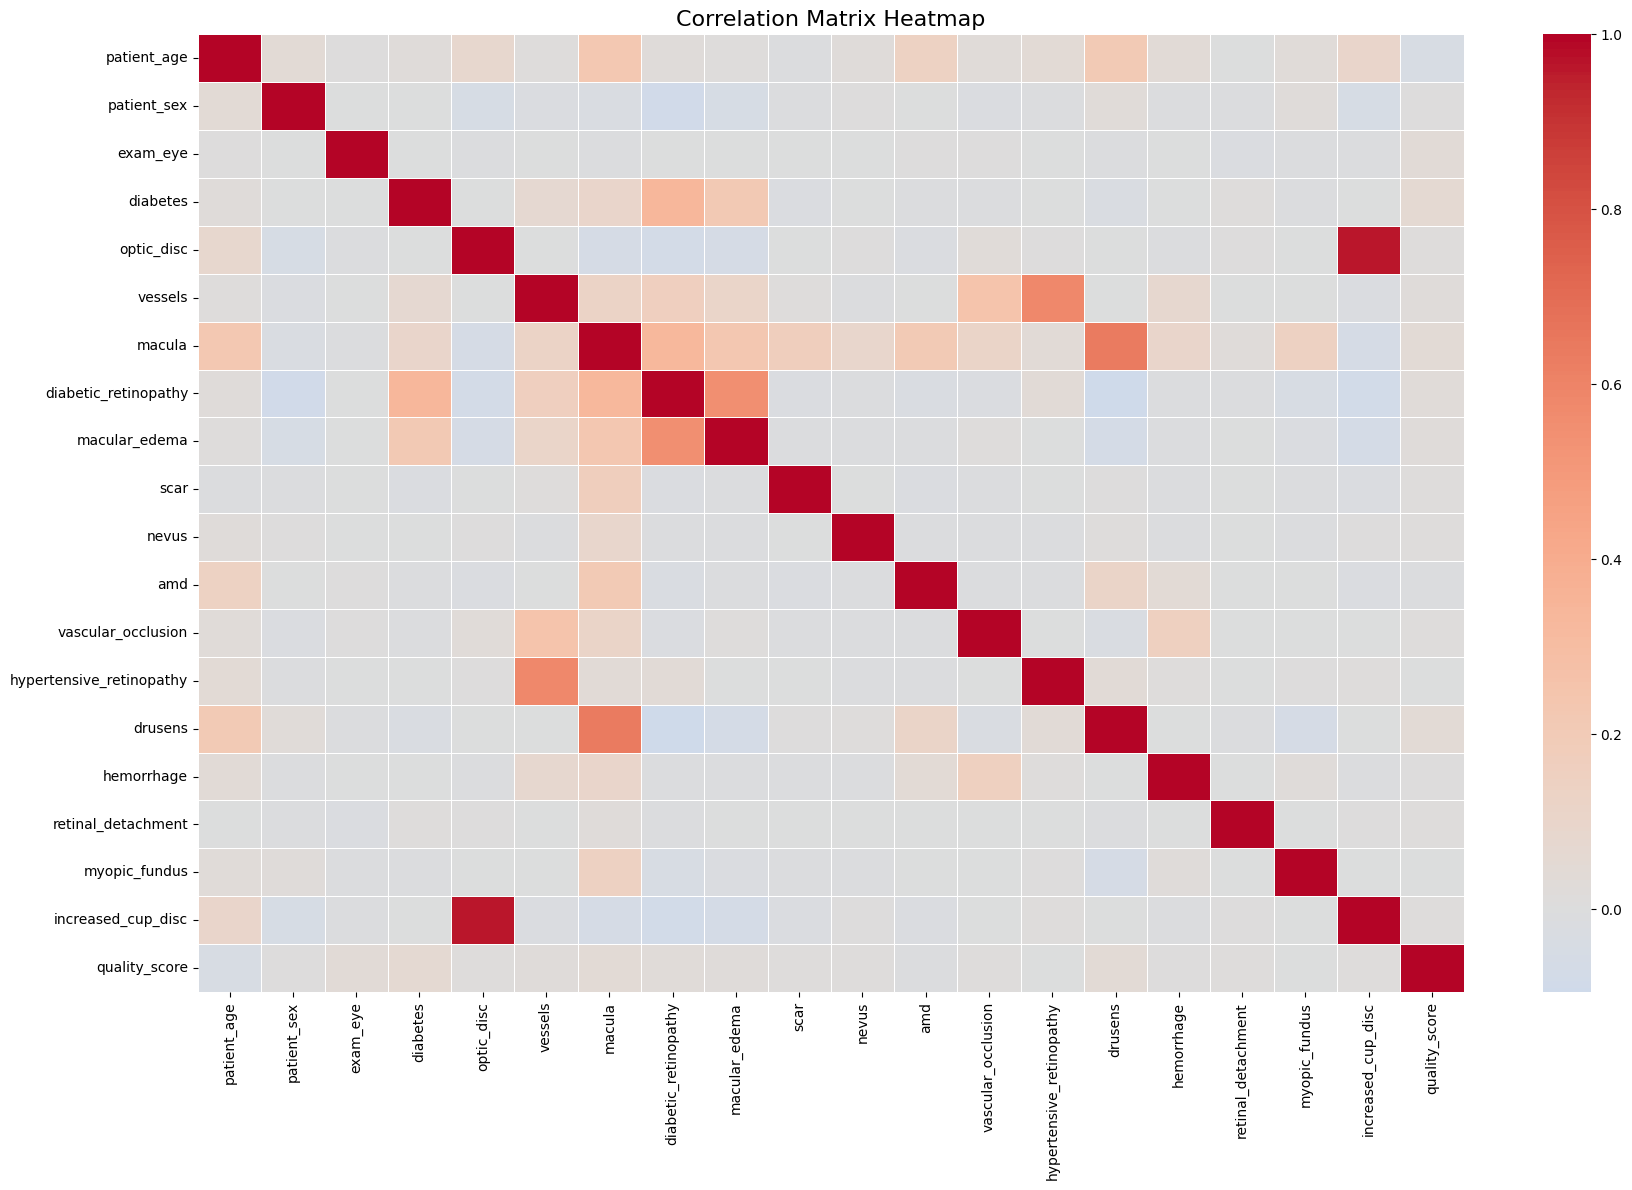

In [ ]:
# 1. Select numeric features only
data2_clean = data2.select_dtypes(include=['int64', 'float64']).copy()

# 2. Remove ID columns (VERY IMPORTANT)
data2_clean = data2_clean.drop(columns=['patient_id'], errors='ignore')

# 3. Compute correlation matrix
corr_matrix = data2_clean.corr()

# 4. Plot heatmap
plt.figure(figsize=(18, 12))

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    annot=False,          # keep False (too many features)
    cbar=True
)

plt.title("Correlation Matrix Heatmap", fontsize=16)
plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

Features used:
['patient_sex', 'exam_eye', 'diabetes', 'optic_disc', 'vessels', 'macula', 'macular_edema', 'scar', 'nevus', 'amd', 'vascular_occlusion', 'hypertensive_retinopathy', 'drusens', 'hemorrhage', 'retinal_detachment', 'myopic_fundus', 'increased_cup_disc']
Accuracy: 0.8932001536688436

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.89      0.94      2432
           1       0.37      0.92      0.53       171

    accuracy                           0.89      2603
   macro avg       0.68      0.90      0.74      2603
weighted avg       0.95      0.89      0.91      2603


Feature Importance:
macula                      0.362619
diabetes                    0.280016
macular_edema               0.151986
drusens                     0.095303
vessels                     0.039325
increased_cup_disc          0.023816
patient_sex                 0.017917
optic_disc                  0.010192
myopic_fundus               0.00933

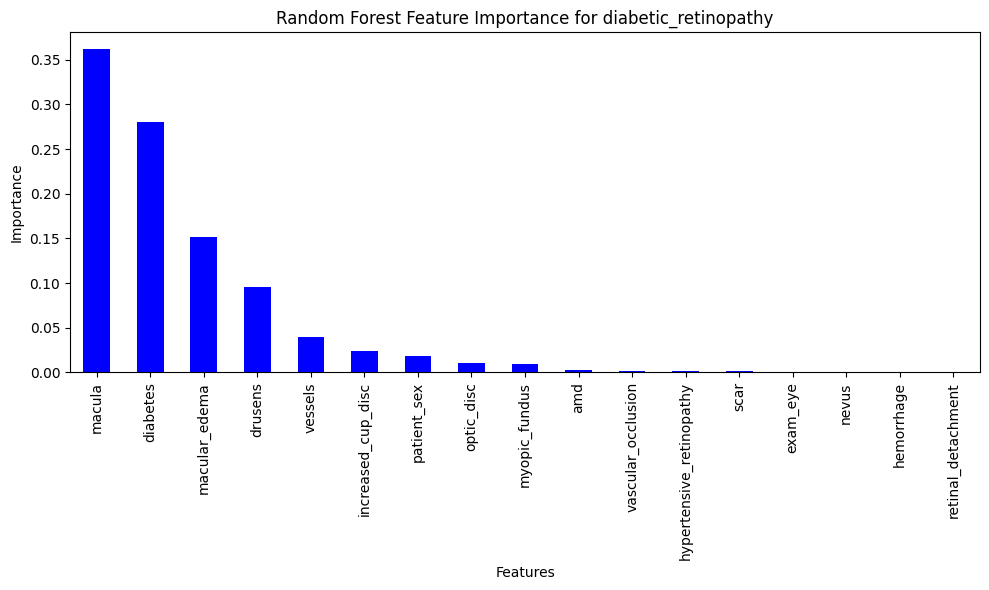

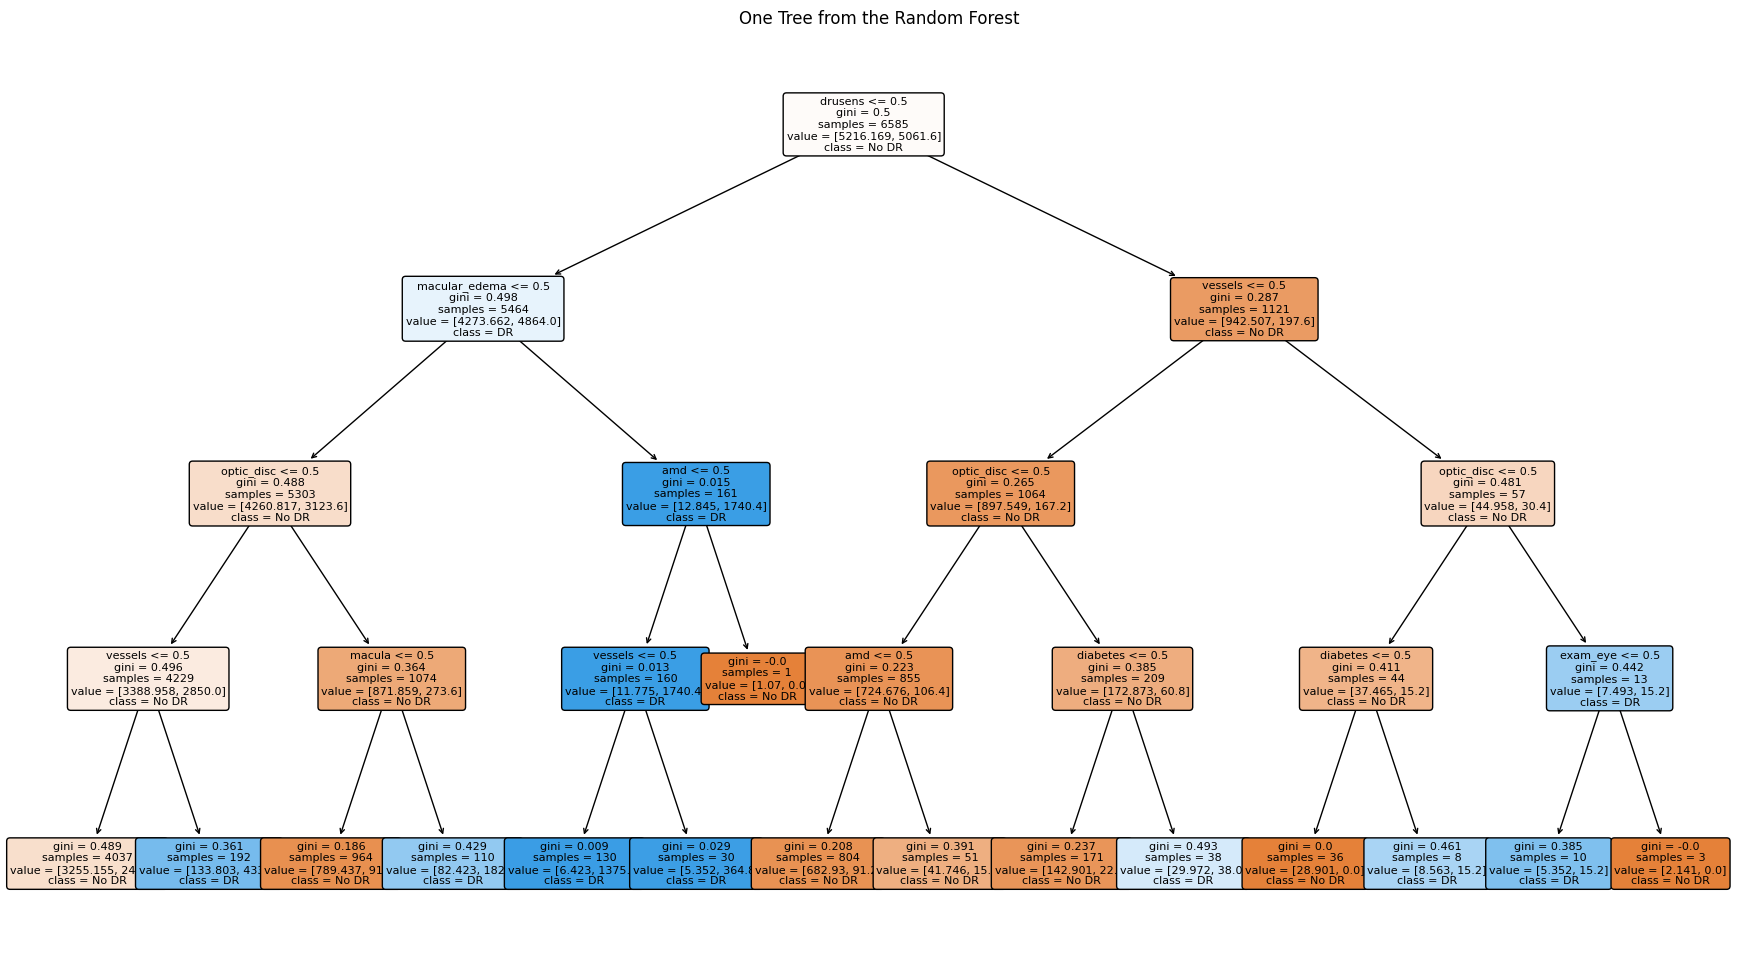

In [105]:
data2_clean = data2.select_dtypes(include=['int64', 'float64']).copy()

# Target
y = data2_clean['diabetic_retinopathy']

# Features
X = data2_clean.drop(columns=['diabetic_retinopathy'], errors='ignore')

# Optional: drop patient_age if you don't want to use it
X = X.drop(columns=['patient_age'], errors='ignore')

print("Features used:")
print(X.columns.tolist())

# =========================
# 2) Train / test split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================
# 3) Train Random Forest
# =========================
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=4,   # keep trees readable
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

rf.fit(X_train, y_train)

# =========================
# 4) Evaluate
# =========================
y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# =========================
# 5) Feature importance
# =========================
feature_importance = pd.Series(rf.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

print("\nFeature Importance:")
print(feature_importance)

plt.figure(figsize=(10, 6))
feature_importance.plot(kind='bar',color='blue')
plt.title("Random Forest Feature Importance for diabetic_retinopathy")
plt.ylabel("Importance")
plt.xlabel("Features")
plt.tight_layout()
plt.show()

# =========================
# 6) Visualize ONE tree from the forest
# =========================
plt.figure(figsize=(22, 12))
plot_tree(
    rf.estimators_[0],
    feature_names=X.columns,
    class_names=['No DR', 'DR'],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("One Tree from the Random Forest")
plt.show()

In [ ]:
from sklearn.metrics import f1_score
print("F1-score:", f1_score(y_test, y_pred))

F1-score: 0.5367521367521367


In [ ]:
print(data2.info())
print(data2.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13015 entries, 0 to 13014
Data columns (total 34 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   image_id                  13015 non-null  object 
 1   patient_id                13015 non-null  int64  
 2   camera                    13015 non-null  object 
 3   patient_age               8669 non-null   float64
 4   comorbidities             6396 non-null   object 
 5   diabetes_time_y           1545 non-null   object 
 6   insuline                  1381 non-null   object 
 7   patient_sex               13015 non-null  int64  
 8   exam_eye                  13015 non-null  int64  
 9   diabetes                  13015 non-null  object 
 10  nationality               13015 non-null  object 
 11  optic_disc                13015 non-null  int64  
 12  vessels                   13015 non-null  int64  
 13  macula                    13015 non-null  int64  
 14  DR_SDR